# 08 — Analyse SHAP — Interpretabilite des 3 Modeles
**Objectif :** Expliquer les predictions des 3 modeles via SHAP et identifier les features les plus influentes.

> SHAP (SHapley Additive exPlanations) attribue a chaque feature une valeur d'impact pour chaque prediction individuelle.

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
import joblib
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import pandas as pd, numpy as np
df = pd.read_csv('Gasification Dataset.csv', delimiter=';')
df.columns = df.columns.str.strip()
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()
df.loc[df['Hydrogen'] < 0, 'Hydrogen'] = 0.0
group_cols = ['ProcessTemperature','AgentType','AgentFlow','SampleType','CatalystType','CatalystRatio']
df['Experiment_Group'] = df.groupby(group_cols).ngroup()
df = df.sort_values(['Experiment_Group','Time']).reset_index(drop=True)
rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(df['Experiment_Group'].unique())
remap = {old: new for new, old in enumerate(shuffled_ids)}
df['Experiment_Group'] = df['Experiment_Group'].map(remap)
g = df.groupby('Experiment_Group')
max_t = g['Time'].transform('max')
df['Relative_Time']         = df['Time'] / (max_t + 1e-6)
df['Thermal_Work']          = df['Temperature'] * df['Time']
df['Agent_Intensity']       = df['AgentFlow'] * df['ProcessTemperature']
df['Thermal_Acceleration']  = df['Thermal_Work'] / (df['Time'] + 0.1)
df['Relative_Severity']     = df['Relative_Time'] * df['ProcessTemperature']
df['Kinetic_Agent_Density'] = df['AgentFlow'] * df['Relative_Time']
df['Cumul_Temp']            = g['Temperature'].cumsum()
df['Temp_Norm_in_Run']      = g['Temperature'].transform(lambda x: (x-x.min())/(x.max()-x.min()+1e-6))
df['Temp_x_AgentFlow']      = df['Temperature'] * df['AgentFlow']
df['Temp_x_CatalystRatio']  = df['Temperature'] * df['CatalystRatio']
df['Cumul_x_AgentFlow']     = df['Cumul_Temp']  * df['AgentFlow']
df['Temp_squared']          = df['Temperature'] ** 2
df['Cumul_Temp_squared']    = df['Cumul_Temp']  ** 2
df['Temp_mean_run']         = g['Temperature'].transform('mean')
df['Temp_max_run']          = g['Temperature'].transform('max')
df['Temp_std_run']          = g['Temperature'].transform('std').fillna(0)
num_cols = ['Time','Temperature','ProcessTemperature','AgentFlow','CatalystRatio',
    'Relative_Time','Thermal_Work','Agent_Intensity','Thermal_Acceleration',
    'Relative_Severity','Kinetic_Agent_Density','Cumul_Temp','Temp_Norm_in_Run',
    'Temp_x_AgentFlow','Temp_x_CatalystRatio','Cumul_x_AgentFlow',
    'Temp_squared','Cumul_Temp_squared','Temp_mean_run','Temp_max_run','Temp_std_run']
cat_cols = ['AgentType','SampleType','CatalystType']
X = df[num_cols + cat_cols]; y = df['Hydrogen']; groups = df['Experiment_Group']

In [3]:
# ── Encoder les features pour SHAP ─────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
X_encoded = preprocessor.fit_transform(X)
ohe_cols   = preprocessor.named_transformers_['cat']\
                          .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_cols
X_enc_df  = pd.DataFrame(X_encoded, columns=feature_names)

# Sous-echantillon 500 obs pour la vitesse
idx_shap     = np.random.default_rng(0).choice(len(X_enc_df), 500, replace=False)
X_shap_small = X_enc_df.iloc[idx_shap]
print(f"Dataset SHAP : {X_shap_small.shape[0]} observations × {X_shap_small.shape[1]} features")

Dataset SHAP : 500 observations × 28 features


In [4]:
# ── Charger ou reentrainer les 3 modeles ───────────────────────
import os

def get_model(name, pkl_path, estimator):
    if os.path.exists(pkl_path):
        pipe = joblib.load(pkl_path)
        print(f"✅ {name} charge depuis {pkl_path}")
        # Extraire le regressor du pipeline
        return pipe.named_steps['regressor'] if hasattr(pipe, 'named_steps') else pipe
    else:
        print(f"⚠️  {name} : fichier .pkl non trouve — reentrainement...")
        estimator.fit(X_enc_df, y)
        return estimator

rf_model  = get_model("Random Forest",  "models/model_rf.pkl",
                       RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1))
et_model  = get_model("Extra Trees",    "models/model_extra_trees.pkl",
                       ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1))
xgb_model = get_model("XGBoost",        "models/model_xgb.pkl",
                       XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                                    random_state=42, n_jobs=-1, verbosity=0))

# Si modeles charges depuis pipeline, reentrainer sur X_enc_df
for name, model in [("RF", rf_model), ("ET", et_model), ("XGB", xgb_model)]:
    try:
        model.predict(X_enc_df.iloc[:2])
    except:
        print(f"Reentrainement {name}...")
        model.fit(X_enc_df, y)

✅ Random Forest charge depuis models/model_rf.pkl
✅ Extra Trees charge depuis models/model_extra_trees.pkl
✅ XGBoost charge depuis models/model_xgb.pkl


In [5]:
# ── Calcul des valeurs SHAP ─────────────────────────────────────
print("Calcul SHAP Random Forest...")
exp_rf   = shap.TreeExplainer(rf_model)
shap_rf  = exp_rf.shap_values(X_shap_small)

print("Calcul SHAP Extra Trees...")
exp_et   = shap.TreeExplainer(et_model)
shap_et  = exp_et.shap_values(X_shap_small)

print("Calcul SHAP XGBoost...")
exp_xgb  = shap.TreeExplainer(xgb_model)
shap_xgb = exp_xgb.shap_values(X_shap_small)

print("✅ SHAP calcule pour les 3 modeles")

Calcul SHAP Random Forest...
Calcul SHAP Extra Trees...
Calcul SHAP XGBoost...
✅ SHAP calcule pour les 3 modeles


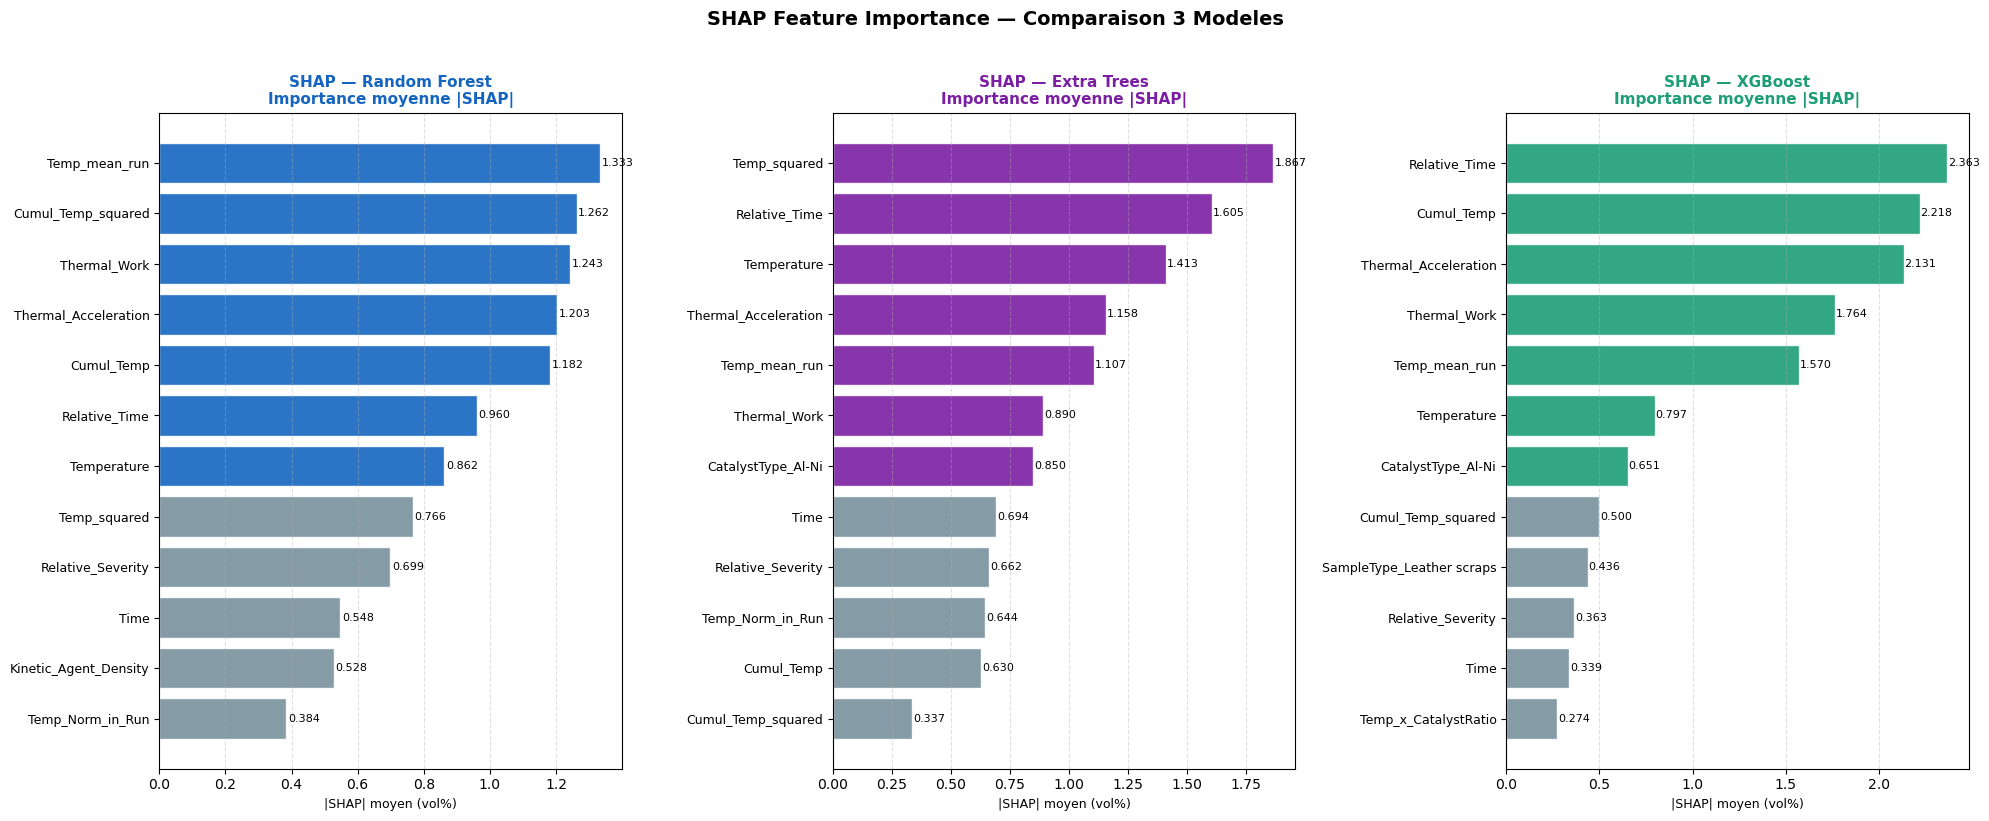

In [6]:
# ── Graphique 1 : Importance SHAP moyenne absolue — 3 modeles ──
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
TOP_N = 12

models_shap = [("Random Forest", shap_rf, "#1565C0"),
               ("Extra Trees",   shap_et, "#7B1FA2"),
               ("XGBoost",       shap_xgb,"#1D9E75")]

for ax, (name, sv, color) in zip(axes, models_shap):
    imp = np.abs(sv).mean(axis=0)
    s   = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(TOP_N)
    colors_bars = [color if i < 3 else color+"99" if i < 7 else "#78909C"
                   for i in range(len(s))]
    ax.barh(range(len(s)), s.values[::-1], color=colors_bars[::-1], edgecolor='white', alpha=0.9)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index[::-1], fontsize=9)
    ax.set_title(f"SHAP — {name}\nImportance moyenne |SHAP|", fontsize=11,
                 fontweight='bold', color=color)
    ax.set_xlabel("|SHAP| moyen (vol%)", fontsize=9)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    for i, val in enumerate(s.values[::-1]):
        ax.text(val+0.005, i, f'{val:.3f}', va='center', fontsize=8)

fig.suptitle("SHAP Feature Importance — Comparaison 3 Modeles",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('SHAP_importance_3modeles.png', dpi=150, bbox_inches='tight')
plt.show()

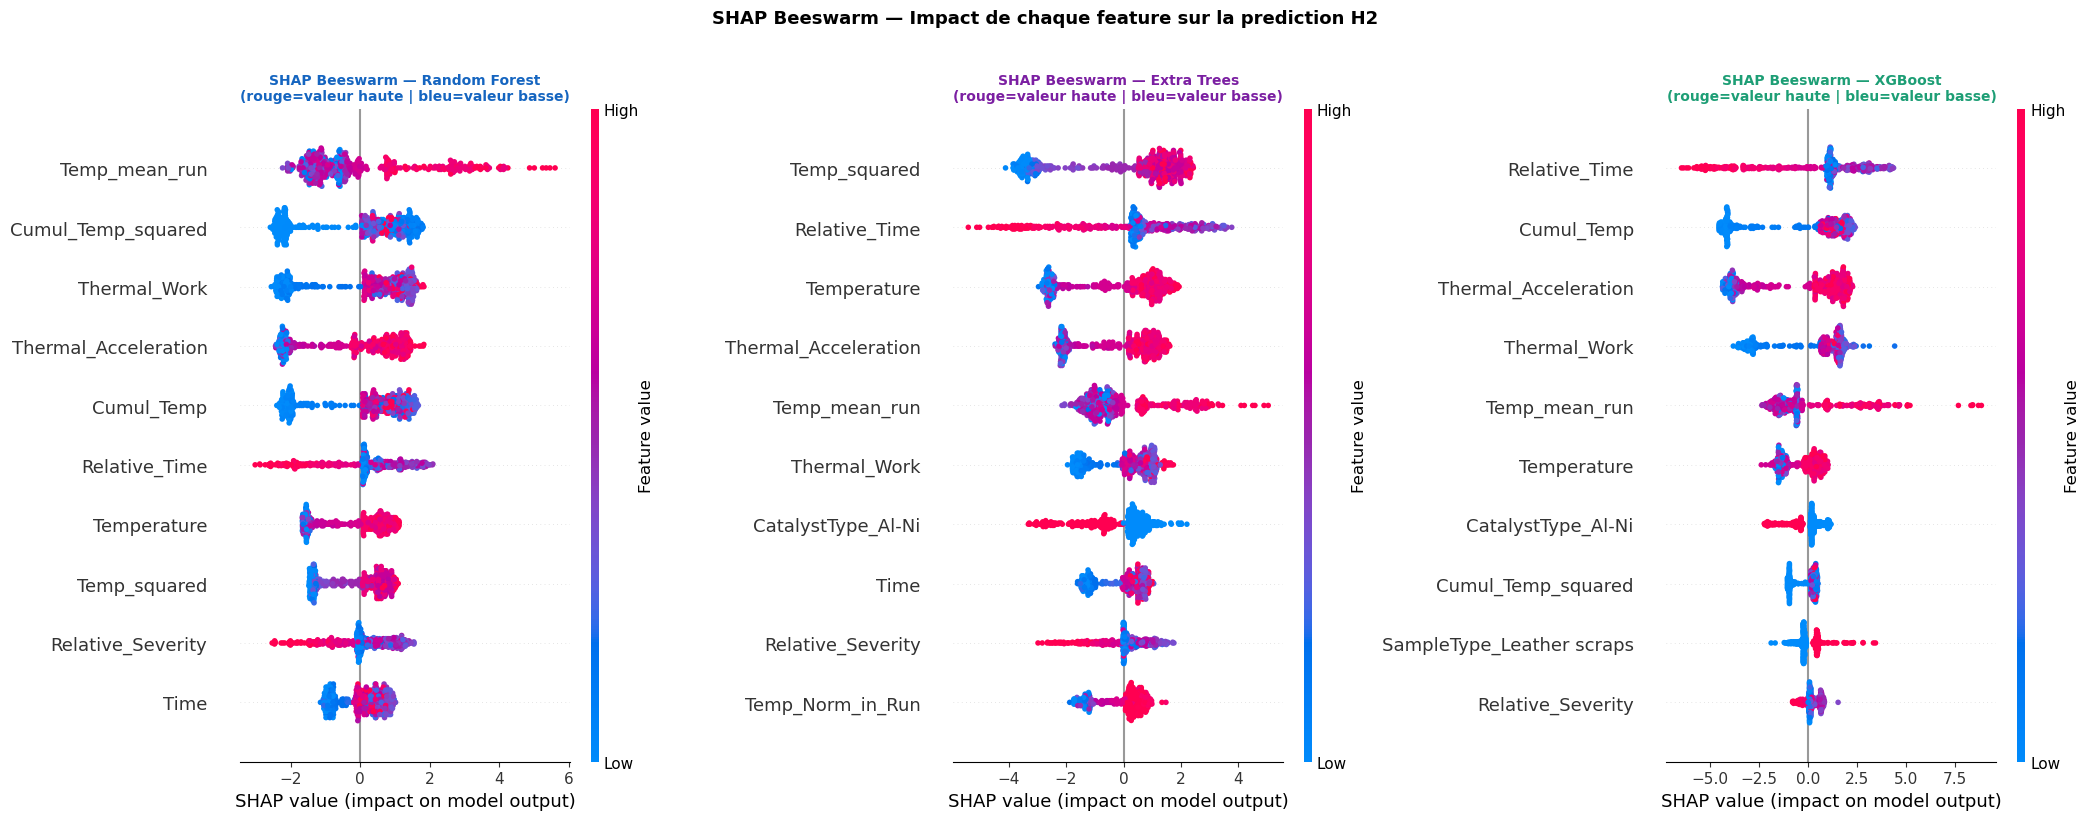

In [7]:
# ── Graphique 2 : Beeswarm plots — 3 modeles ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

for ax, (name, sv, color) in zip(axes, models_shap):
    plt.sca(ax)
    shap.summary_plot(sv, X_shap_small, feature_names=feature_names,
                      max_display=10, show=False, plot_size=None, color_bar=True)
    ax.set_title(f"SHAP Beeswarm — {name}\n(rouge=valeur haute | bleu=valeur basse)",
                 fontsize=10, fontweight='bold', color=color)

fig.suptitle("SHAP Beeswarm — Impact de chaque feature sur la prediction H2",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('SHAP_beeswarm_3modeles.png', dpi=150, bbox_inches='tight')
plt.show()

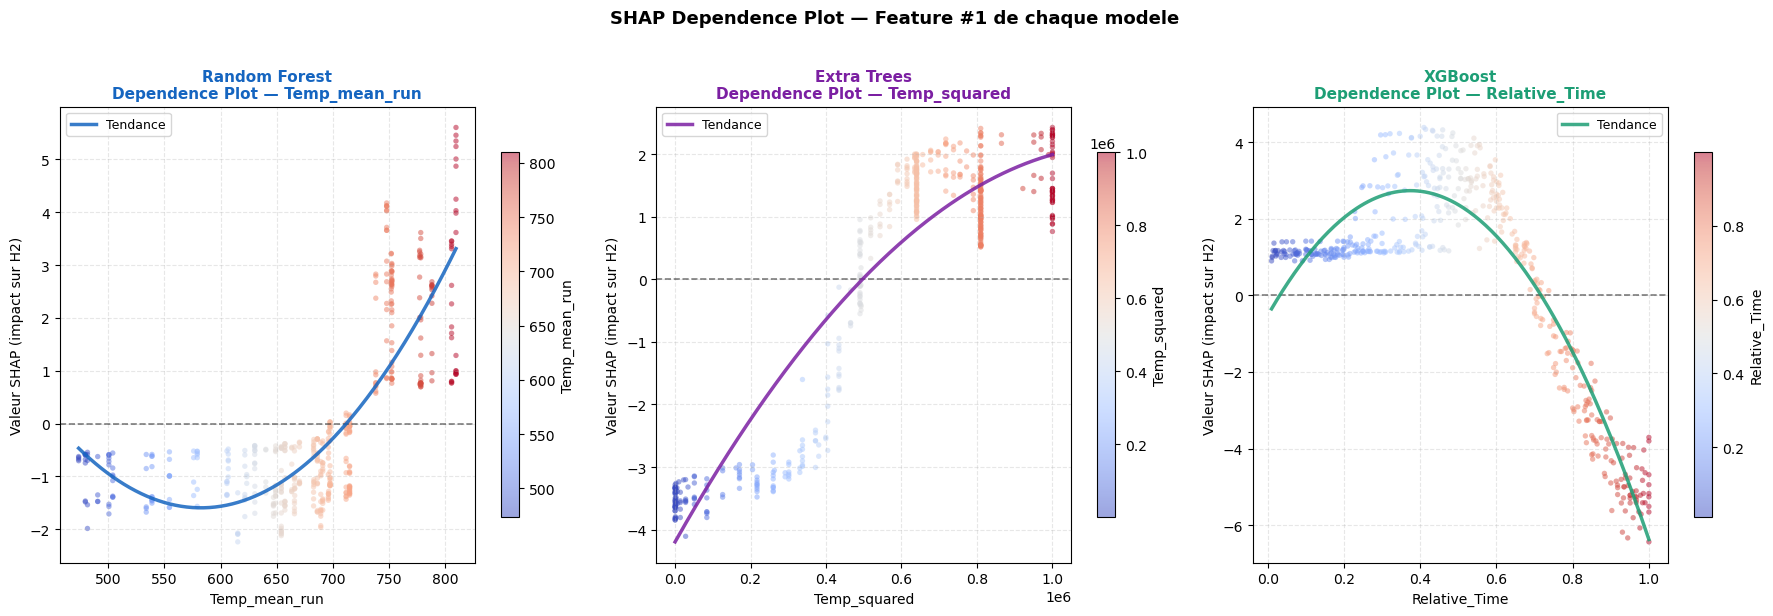


✅ 3 graphiques SHAP sauvegardes


In [8]:
# ── Graphique 3 : Dependence Plot — feature #1 de chaque modele ─
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, sv, color) in zip(axes, models_shap):
    imp = np.abs(sv).mean(axis=0)
    top_feat = pd.Series(imp, index=feature_names).idxmax()
    feat_idx = list(feature_names).index(top_feat)

    feat_vals  = X_shap_small[top_feat].values
    shap_vals_f = sv[:, feat_idx]

    sc = ax.scatter(feat_vals, shap_vals_f, c=feat_vals,
                    cmap='coolwarm', alpha=0.5, s=15, edgecolors='none')
    ax.axhline(0, color='black', lw=1.2, ls='--', alpha=0.5)
    z = np.polyfit(feat_vals, shap_vals_f, 2)
    p = np.poly1d(z)
    xl = np.linspace(feat_vals.min(), feat_vals.max(), 200)
    ax.plot(xl, p(xl), color=color, lw=2.5, alpha=0.85, label='Tendance')
    plt.colorbar(sc, ax=ax, shrink=0.8, label=top_feat)
    ax.set_xlabel(top_feat, fontsize=10)
    ax.set_ylabel("Valeur SHAP (impact sur H2)", fontsize=10)
    ax.set_title(f"{name}\nDependence Plot — {top_feat}",
                 fontsize=11, fontweight='bold', color=color)
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle("SHAP Dependence Plot — Feature #1 de chaque modele",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('SHAP_dependence_3modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ 3 graphiques SHAP sauvegardes")

In [9]:
# ── Résumé SHAP — insights scientifiques ───────────────────────
print("="*65)
print("  INSIGHTS SHAP — TOP 5 FEATURES PAR MODELE")
print("="*65)
for name, sv, _ in models_shap:
    imp = np.abs(sv).mean(axis=0)
    top5 = pd.Series(imp, index=feature_names).sort_values(ascending=False).head(5)
    print(f"\n{name} :")
    for i, (feat, val) in enumerate(top5.items()):
        print(f"  {i+1}. {feat:30s} |SHAP| moy = {val:.4f}")
print("\n💡 Les 3 modeles confirment : Energie thermique cumulee = facteur dominant de H2")

  INSIGHTS SHAP — TOP 5 FEATURES PAR MODELE

Random Forest :
  1. Temp_mean_run                  |SHAP| moy = 1.3328
  2. Cumul_Temp_squared             |SHAP| moy = 1.2620
  3. Thermal_Work                   |SHAP| moy = 1.2434
  4. Thermal_Acceleration           |SHAP| moy = 1.2034
  5. Cumul_Temp                     |SHAP| moy = 1.1817

Extra Trees :
  1. Temp_squared                   |SHAP| moy = 1.8673
  2. Relative_Time                  |SHAP| moy = 1.6052
  3. Temperature                    |SHAP| moy = 1.4129
  4. Thermal_Acceleration           |SHAP| moy = 1.1577
  5. Temp_mean_run                  |SHAP| moy = 1.1069

XGBoost :
  1. Relative_Time                  |SHAP| moy = 2.3633
  2. Cumul_Temp                     |SHAP| moy = 2.2181
  3. Thermal_Acceleration           |SHAP| moy = 2.1313
  4. Thermal_Work                   |SHAP| moy = 1.7636
  5. Temp_mean_run                  |SHAP| moy = 1.5699

💡 Les 3 modeles confirment : Energie thermique cumulee = facteur dominan